Linear Algebra I

Part A — the curriculum activities

Task 01

Visualise 2D vectors and their arithmetic

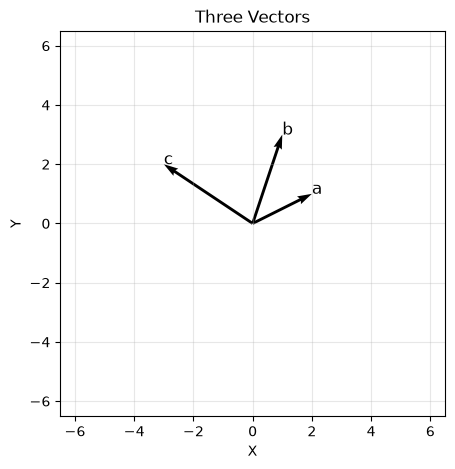

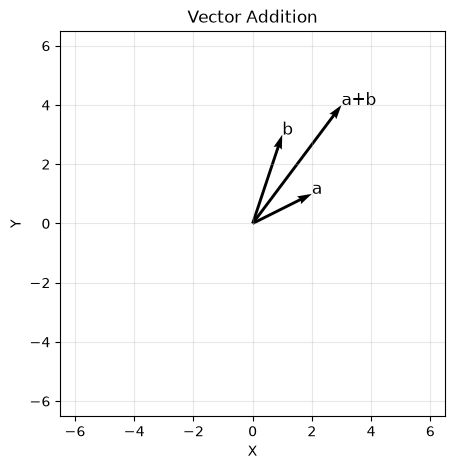

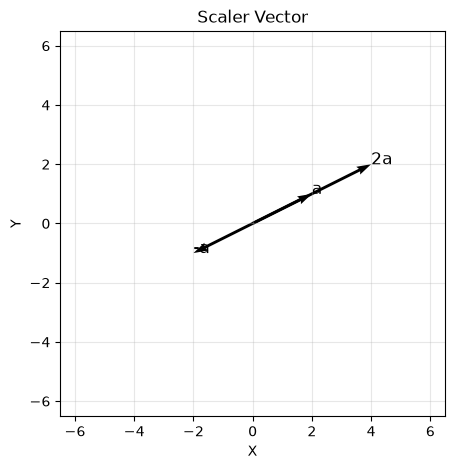

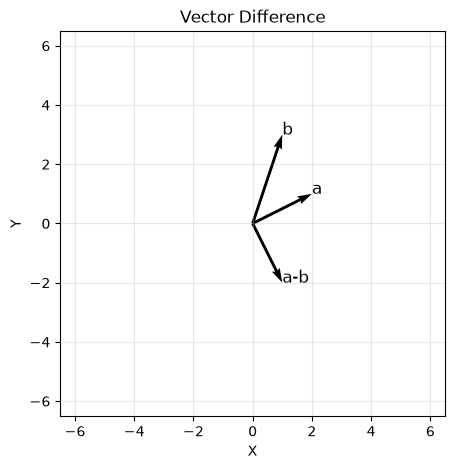

In [1]:
# Way 1 :-

import matplotlib.pyplot as plt

def draw(vectors, labels, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    for v, l in zip(vectors, labels):
        ax.quiver(0, 0, v[0], v[1], angles = "xy", scale_units = "xy", scale = 1)
        ax.text(v[0], v[1], l, fontsize=12)

    ax.set_xlim(-6.5, 6.5)
    ax.set_ylim(-6.5, 6.5)

    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)

    plt.show()

# Draw three vectors :-
a = [2, 1]
b = [1, 3]
c = [-3, 2]
draw([a, b, c], ["a", "b", "c"], "Three Vectors")

# Draw a, b, a+b
sum_vector = [a[0] + b[0], a[1] + b[1]]
draw([a, b, sum_vector], ["a", "b", "a+b"], "Vector Addition")

# Draw a, 2a, -a
double_a = [2 * a[0], 2 * a[1]]
minus_a = [-a[0], -a[1]]
draw([a, double_a, minus_a], ["a", "2a", "-a"], "Scaler Vector")
# Multiplying a vector by 2 doubles its length but keeps the same direction.
# Multiplying by -1 keeps the length the same but reverses the direction.

# Draw a, b, a-b
sub_vector = [a[0] - b[0], a[1] - b[1]]
draw([a, b, sub_vector], ["a", "b", "a-b"], "Vector Difference")

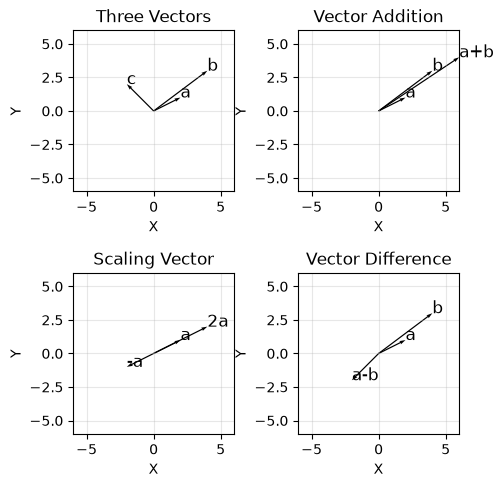

In [47]:
# Way 2 :-

import matplotlib.pyplot as plt

def draw(ax, vectors, labels, title):
    
    for v, l in zip(vectors, labels):
        ax.quiver(0, 0, v[0], v[1], angles = "xy", scale_units = "xy", scale = 1)
        ax.text(v[0], v[1], l, fontsize=12)

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    
fig, ax = plt.subplots(2, 2, figsize=(5, 5))


# Draw three vectors
a = [2, 1]
b = [4, 3]
c = [-2, 2]

draw(ax[0,0], [a, b, c], ["a", "b", "c"], "Three Vectors")

# Draw a, 2a and a + b
sum_vector = [a[0] + b[0], a[1] + b[1]]
draw(ax[0,1], [a, b, sum_vector], ["a", "b", "a+b"], "Vector Addition")

# Draw a, 2a, -a
double_a = [2 * a[0], 2 * a[1]]
minus_a = [-a[0], -a[1]]
draw(ax[1,0], [a, double_a, minus_a], ["a", "2a", "-a"], "Scaling Vector")

# Draw a - b
sub_vector = [a[0] - b[0], a[1] - b[1]]
draw(ax[1,1], [a, b, sub_vector], ["a", "b", "a-b"], "Vector Difference")

plt.tight_layout()
plt.show()

Task 02

Compute angles between vectors

In [45]:
import numpy as np

def angle_between(a, b):
    cos_theta = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))
    cos_theta = np.clip(cos_theta, -1, 1)
    return np.degrees(np.arccos(cos_theta))

# For perpendicular vectors :-
v1 = np.array([1, 0])
v2 = np.array([0, 1])
print("Perpendicular : ", angle_between(v1, v2), "degrees")

# For indentical vectors :-
v3 = np.array([2, 3])
v4 = np.array([2, 3])
print("Indentical : ", angle_between(v3, v4), "degrees")

# For opposite vectors :-
v5 = np.array([1, 0])
v6 = np.array([-1, 0])
print("Opposite : ", angle_between(v5, v6), "degrees")

# v7 = np.array([1, 0])
# v8 = np.array([1, 1])
# print(angle_between(v7, v8), "degrees")
# output 45.00000000000001 degrees

# Student Exam score vector :-
student_1 = np.array([80, 75, 92])
student_2 = np.array([72, 86, 74])
print("\nStudent angle : ", angle_between(student_1, student_2), "degrees")

# Scaling does not change angle 
a = np.array([2, 3])
b = np.array([1, 4])

angle1 = angle_between(a, b)
angle2 = angle_between(a, 5 * b)
print("\nAngle(a,b) = ", angle1)
print("Angle(a, 5 * b) = ", angle2)

# Outputs are same.
# Scaling a vector changes only the magnitude(length), not its direction. 
# Since the scale factor cancels out in the cosine formula, the angle remains unchanged. 

Perpendicular :  90.0 degrees
Indentical :  0.0 degrees
Opposite :  180.0 degrees

Student angle :  8.596169996508063 degrees

Angle(a,b) =  19.653824058053292
Angle(a, 5 * b) =  19.653824058053313


Task 03

Implement Gram-Schmidt orthogonalisation

In [52]:
import numpy as np

def gram_schmidth(vectors):
    basis = []

    for v in vectors:
        w = v.astype(float).copy()

        for b in basis:
            w = w - (v @ b) * b

        norm = np.linalg.norm(w)
        if norm > 1e-10:
            basis.append(w / norm)

    return np.array(basis)
    

# Independent Vectors
vectors = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1]
])

Q = gram_schmidth(vectors)

print("Orthonormal basis : ")
print(Q)

print("\nQ @ Q.T")
print(Q @ Q.T)

print("\nOriginal Rank : ", np.linalg.matrix_rank(vectors))
print("Basis Rank : ", np.linalg.matrix_rank(Q))


# Dependent Vectors
vectors_dep = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [2, 1, 1]
])

Q_dep = gram_schmidth(vectors_dep)

print("\nDependent Set : ")
print(Q_dep)

Q_np, R = np.linalg.qr(vectors)

print("\nGram-Schmidth Basis : ")
print(Q)

print("\nNumpy QR Basis : ")
print(Q_np.T)

Orthonormal basis : 
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

Q @ Q.T
[[ 1.00000000e+00  1.03018891e-16  1.51811967e-16]
 [ 1.03018891e-16  1.00000000e+00 -1.59104334e-16]
 [ 1.51811967e-16 -1.59104334e-16  1.00000000e+00]]

Original Rank :  3
Basis Rank :  3

Dependent Set : 
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]]

Gram-Schmidth Basis : 
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

Numpy QR Basis : 
[[-0.70710678 -0.70710678 -0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]


Task 04

Prove that dot product zero means perpendicular

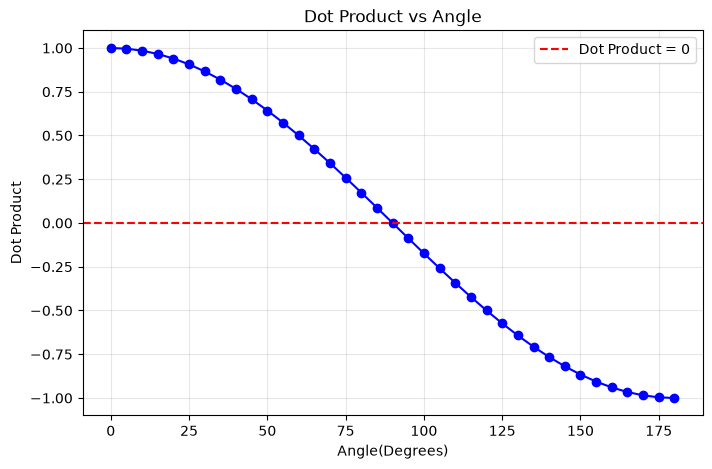

 Angle        Dot product
 90degree     0.0000000000

Every pair with a 90degree angle has a dot product approximately equal to zero.


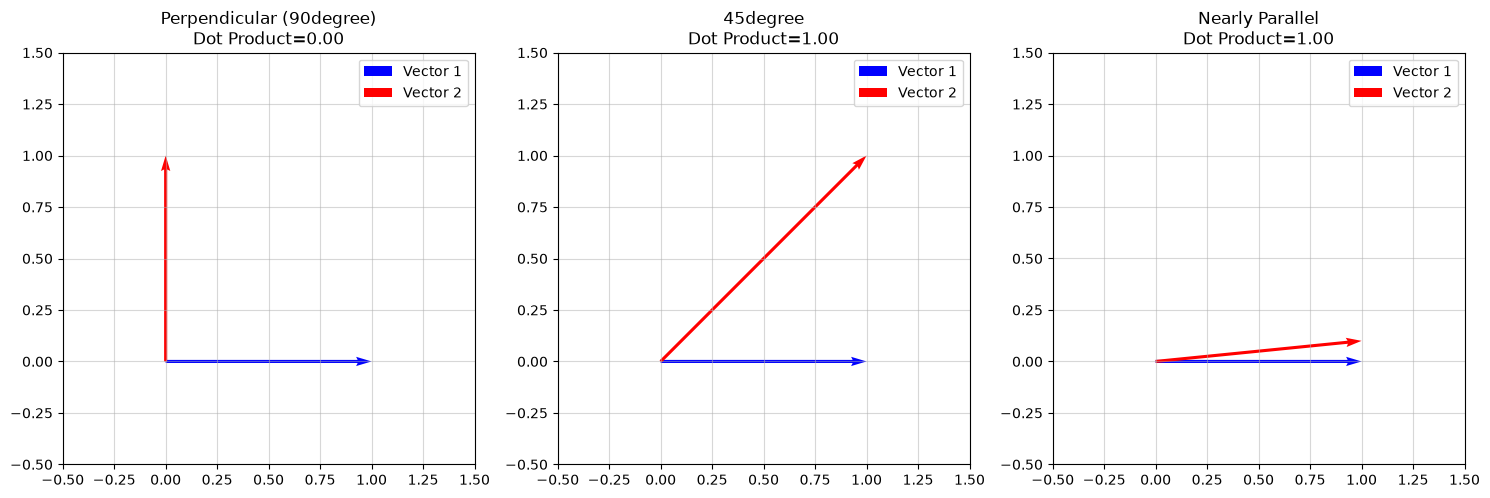


Specific Vector Pairs
Perpendicular (90degree)
Vector 1 : [1 0]
Vector 2 : [0 1]
Dot Product : 0.00
Angle : 90.00
-----------------------------------
45degree
Vector 1 : [1 0]
Vector 2 : [1 1]
Dot Product : 1.00
Angle : 45.00
-----------------------------------
Nearly Parallel
Vector 1 : [1 0]
Vector 2 : [1.  0.1]
Dot Product : 1.00
Angle : 5.71
-----------------------------------

Conclusion
1. The dot product crosses zero at 90 degree.
2. Every pair with a 90 degree angle has a dot product close to zero.
3. A zero dot product means the vectors are perpendicular because cos(90 degree) = 0.


In [70]:
import numpy as np
import matplotlib.pyplot as plt

angles = []
dots = []


# Base Vector
base = np.array([1.0, 0.0])

for deg in range(0, 181, 5):
    
    rad = np.radians(deg)

    # Unit vector at current angle
    v = np.array([np.cos(rad), np.sin(rad)])

    # Dot product
    dot = np.dot(base, v)

    angles.append(deg)
    dots.append(dot)


# Plot dot product vs angle
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(angles, dots, marker="o", color='blue')

ax.axhline(0, color='red', linestyle='--', label='Dot Product = 0')

ax.set_title("Dot Product vs Angle")
ax.set_xlabel("Angle(Degrees)")
ax.set_ylabel("Dot Product")

ax.grid(alpha=0.3)
ax.legend()

plt.show()


# Verify Dot product = 0 at 90degree
print(" Angle        Dot product")

for angle, dot in zip(angles, dots):
    if np.isclose(dot, 0):
        print(f"{angle:3d}degree     {dot:.10f}")

print("\nEvery pair with a 90degree angle has a dot product approximately equal to zero.")


# Three specific vector paris
pairs = [
    ("Perpendicular (90degree)",
     np.array([1, 0]),
     np.array([0, 1])),

    ("45degree",
     np.array([1, 0]),
     np.array([1, 1])),

    ("Nearly Parallel",
     np.array([1, 0]),
     np.array([1, 0.1]))
]


# Draw the three vector pairs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, v1, v2) in zip(axes, pairs):
    dot = np.dot(v1, v2)

    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Vector 1')
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color="red", label='Vector 2')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_aspect("equal")
    ax.grid(alpha=0.5)

    ax.set_title(f"{title}\nDot Product={dot:.2f}")

    ax.legend()

plt.tight_layout()
plt.show()


# Compute angles for the three pairs
print("\nSpecific Vector Pairs")

for title, v1, v2 in pairs:
    dot = np.dot(v1, v2)

    angle = np.degrees(np.arccos(np.clip(dot / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1, 1)))

    print(f"{title}")
    print(f"Vector 1 : {v1}")
    print(f"Vector 2 : {v2}")
    print(f"Dot Product : {dot:.2f}")
    print(f"Angle : {angle:.2f}")
    print("-"*35)


# Final Conclusion
print("\nConclusion")
print("1. The dot product crosses zero at 90 degree.")
print("2. Every pair with a 90 degree angle has a dot product close to zero.")
print("3. A zero dot product means the vectors are perpendicular because cos(90 degree) = 0.")

Part B — apply the geometry

Task 05

Build a tiny search engine

In [75]:
import numpy as np

vocab = ['ml','data','model','cook','recipe','food']

docs = np.array([
    [8, 6, 4, 0, 0, 1],
    [0, 1, 0, 7, 8, 6],
    [6, 5, 3, 6, 6, 5],
    [40, 30, 20, 0, 0, 5],
    [5, 4, 3, 0, 0, 0]
])

doc_names = ['D1', 'D2', 'D3', 'D4', 'D5']

# Query
query = np.array([9, 7, 5, 0, 0, 0])

# Cosine Similarity Function
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Cosine Ranking
cos_scores = []
for doc in docs :
    cos_scores.append(cosine(query, doc))

cos_scores = np.array(cos_scores)

rank = np.argsort(cos_scores)[::-1]

print("Cosine Similarity Ranking\n")

for i in rank :
    print(f"{doc_names[i]} : {cos_scores[i]:.4f}")

# Raw Dot Product Ranking
dot_scores = docs @ query
rank2 = np.argsort(dot_scores)[::-1]
print("\nRaw Dot Product Ranking\n")

for i in rank2:
    print(f"{doc_names[i]} : {dot_scores[i]}")

# Cosine similarity compares the direction of documents vectors instead of their magnitude,making it
# insensitive to document lenth. This allows documents with similar topics but different sizes to recieve
# similar similarity scores, making cosine a better choice than the row dot product for document retrieval.

Cosine Similarity Ranking

D5 : 0.9996
D4 : 0.9951
D1 : 0.9951
D3 : 0.6464
D2 : 0.0459

Raw Dot Product Ranking

D4 : 670
D1 : 134
D3 : 104
D5 : 88
D2 : 7


Task 06

Detect redundant features

In [90]:
import numpy as np

rng = np.random.default_rng(0)

# Feature 1
height_cm = rng.normal(170, 10, 100)

# Feature 2 (exact linear dependence)
height_in = height_cm / 2.54

# Remaining independent features
weight = rng.normal(70, 15, 100)
age = rng.integers(18, 40, 100)
salary = rng.normal(50000, 8000, 100)

# Feature matrix
x = np.column_stack((height_cm, height_in, weight, age, salary))

print("Shape of matrix : ", x.shape)

# compute matrix rank
rank = np.linalg.matrix_rank(x)
print("\nRank of Feature Matrix = ", rank)
# The rank is 4 instead of 5 because one feature (height_in) is an exact linear multiple of another
# feature (height_cm). Therefore, the matrix has only four independent columns.


# Correlation Check
corr = np.corrcoef(x.T)
print("\n Correlation : ", corr)


# Drop feature one by one
feature_names = ["height_cm", "height_in", "weight", "age", "salary"]

for i in range(x.shape[1]):
    x_drop = np.delete(x, i, axis=1)
    rank = np.linalg.matrix_rank(x_drop)

    print(f"\nAfter removing {feature_names[i]} -> Rank = {rank}")


# Remove reduntant feature
x_new = np.column_stack((height_cm, weight, age, salary))

print("\nShape = ", x_new.shape)
print("Rank = ", np.linalg.matrix_rank(x_new))


# The feature matrix has fewer independent columns than total features.
# This means at least one feature can be expressed as a linear combination of another
# feature, making it redundant.

# height_cm and height_in are redundant because height_in = height_cm / 2.54, making them perfectly linear dependent.

# Perfectly correlated features create multicollinearity, making the feature matrix singular or nearly singular.
# As a result, linear models cannot estimate unique coefficients reliably, leading to unstable or undefined parameter values.

Shape of matrix :  (100, 5)

Rank of Feature Matrix =  4

 Correlation :  [[ 1.          1.          0.05545339 -0.0841543  -0.04110089]
 [ 1.          1.          0.05545339 -0.0841543  -0.04110089]
 [ 0.05545339  0.05545339  1.          0.07692889  0.05352287]
 [-0.0841543  -0.0841543   0.07692889  1.         -0.1129095 ]
 [-0.04110089 -0.04110089  0.05352287 -0.1129095   1.        ]]

After removing height_cm -> Rank = 4

After removing height_in -> Rank = 4

After removing weight -> Rank = 3

After removing age -> Rank = 3

After removing salary -> Rank = 3

Shape =  (100, 4)
Rank =  4
